# n-Armed Bandit

## Preliminaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## Define a stochastic selector

In [2]:
def stochastic_chooser(probs: np.ndarray, n_picks:int, bin_bounds: str = 'ceiling_inclusive'):
    indices = np.arange(0, probs.shape[0])
    cum_probs_ceilings = np.cumsum(probs)
    cum_probs_floors = np.cumsum(np.hstack([0.0, probs[:-1]]).astype(float))
    seeds = np.random.rand(n_picks,)
    
    picks = np.nan*np.ones(n_picks,)
    for i, seed in enumerate(seeds):
        if bin_bounds == 'floor_inclusive':
            ceiling_check = np.logical_or((cum_probs_ceilings > seed), (1.0*np.ones_like(cum_probs_ceilings) <= seed))
            floor_check = (cum_probs_floors <= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]

        if bin_bounds == 'ceiling_inclusive':
            floor_check = np.logical_or((cum_probs_floors < seed), (0.0*np.ones_like(cum_probs_floors) >= seed))
            ceiling_check = (cum_probs_ceilings >= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]
            
        picks[i] = pick
        
    return picks.astype(int)

In [3]:
# test stochastic_chooser
probs = np.array([0.50, 0.15, 0.10, 0.25])
n_picks = 10
#action_indices = stochastic_chooser(probs, n_picks, bin_bounds='floor_inclusive')
action_indices = stochastic_chooser(probs, n_picks, bin_bounds='ceiling_inclusive')
action_indices

array([2, 0, 3, 0, 1, 0, 1, 0, 0, 0])

## Define Probabalistic Reward generator

In [4]:
def stochastic_reward_gen(mean_reward_value: float, standard_dev: float) -> float:
    
    seed = np.random.rand(1)
    # Inverse of the cumulative normal distribution at specified mean and standard_deviation
    reward = stats.norm.ppf(seed, loc=mean_reward_value, scale=standard_dev)
    
    return reward

In [5]:
# Test stochastic_reward_gen()
actual_reward_value = -3.0
standard_dev = 2.25
n_reps = 500
gen_rewards = np.array([
    stochastic_reward_gen(actual_reward_value, standard_dev) for rep in range(0, n_reps)
])
mean_gen_rewards = np.mean(gen_rewards)
stdev_gen_rewards = np.std(gen_rewards)

mean_gen_rewards, stdev_gen_rewards

(-3.0157198722229013, 2.253257876760453)

## Define Action-value estimator

In [95]:
def action_value_estimator(reward: float, last_estimate: float, k_step: int) -> float:
    
    if k_step < 1:
        updated_estimate = last_estimate
    else:
        k_step = float(k_step)
        updated_estimate = last_estimate + (1. / (k_step + 1.)) * (reward - last_estimate)
    
    return updated_estimate

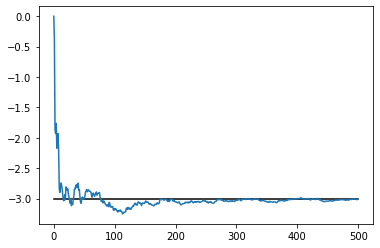

In [7]:
# test action_value_estimator
action_value_estimates = np.nan*np.ones_like(gen_rewards)
action_value_estimates[0] = 0.

for i, gen_reward in enumerate(gen_rewards[:-1]):
    k = i + 1
    action_value_estimates[k] = action_value_estimator(gen_reward, action_value_estimates[i], k)

plt.plot([0, action_value_estimates.shape[0]], [actual_reward_value, actual_reward_value], c="black")
plt.plot(action_value_estimates)

## Define Epsilon Greedy 

In [8]:
def epsilon_greedy_actor(action_value_estimates: np.ndarray, epsilon: float) -> int:
    
    n_actions = action_value_estimates.shape[0]
    action_indices = np.arange(0, n_actions)
    seed = np.random.rand(1)
    if seed < epsilon:
        action_index = np.random.choice(action_indices, size=1, replace=True)
    else:
        action_index = np.argmax(action_value_estimates)
        
    return action_index

In [9]:
# test epsilon_greedy_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
epsilon = 0.5
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = epsilon_greedy_actor(action_value_estimates, epsilon)
    
selections.astype(int)

array([3, 4, 1, 3, 3, 3, 1, 3, 3, 3, 3, 2, 2, 1, 3, 3, 3, 3, 0, 3])

## Define Softmax_actor()

In [10]:
def softmax_actor(action_value_estimates: np.ndarray, tau: float) -> int:

    denom = np.sum(np.exp(action_value_estimates / tau))
    numer = np.exp(action_value_estimates / tau)
    
    probs = (1. / denom) * numer
    #print(f"value of probs: {probs}")
    action_index = stochastic_chooser(probs, n_picks=1, bin_bounds='ceiling_inclusive')
    
    return action_index

In [11]:
# test softmax_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
tau = 10.
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = softmax_actor(action_value_estimates, tau)
    
selections.astype(int)

array([2, 1, 1, 2, 1, 1, 0, 0, 5, 4, 0, 0, 3, 4, 0, 0, 5, 5, 3, 1])

## Random draw from normal distribution

In [12]:
def draw_random_from_normal(n_actions: int, mean: float, std_dev: float) -> np.ndarray:
    
    seeds = np.random.rand(n_actions)
    drawn_values = np.array([stats.norm.ppf(seed, loc=mean, scale=std_dev) for seed in seeds])
    
    return drawn_values

In [13]:
n_actions = 10
action_values_actual = draw_random_from_normal(n_actions, 0., 1.)
action_values_actual = np.sort(action_values_actual)
action_values_actual

array([-1.30181116, -0.92902649, -0.56677503, -0.3501598 , -0.23198267,
        0.23606709,  0.29975473,  0.85818615,  1.194133  ,  1.82231946])

# n-armed bandit

In [152]:
epsilon = 0.01
temperature = 0.5
n_arms = 10
n_runs = 100
n_steps_per_run = 2000

mean_actuals = 0.
stdev_actuals = 1.
stdev_rewards = 1.


actor_greedy = dict(
    function="epsilon-greedy",
    params=(epsilon,)
)

actor_softmax = dict(
    function="softmax_actor",
    params=(temperature,)
)

def n_armed_bandit_solve(n_arms: int, n_runs: int, n_steps_per_run: int, actor: dict) -> list:
    
    runs_record = [{}] * n_runs
    for run_i in range(0, n_runs):
        action_record = np.nan*np.ones(n_steps_per_run)
        reward_record = np.nan*np.ones(n_steps_per_run)

        action_values_actual = draw_random_from_normal(n_arms, mean_actuals, stdev_actuals)
        best_action = np.argmax(action_values_actual)
        #print(f"Best action: {best_action}")
        #print(f"Action values actual: {action_values_actual}")

        #last_action_value_estimates = draw_random_from_normal(n_arms, mean_actuals, stdev_actuals)
        last_action_value_estimates = np.zeros_like(action_values_actual)
        action_select = np.random.choice(np.arange(0, n_arms))
        action_record[0] = action_select
        reward_record[0] = stochastic_reward_gen(action_values_actual[action_select], stdev_rewards)

        for step_i in range(0, n_steps_per_run - 1):

            step_k = np.sum(action_record == action_select)
            new_action_value_estimates[action_select] = action_value_estimator(
                reward_record[step_i],
                last_action_value_estimates[action_select],
                step_k
            )
            
            if actor["function"] == "epsilon-greedy":
                action_select = epsilon_greedy_actor(
                    new_action_value_estimates, *actor["params"]
                )
                
            if  actor["function"] == "softmax_actor":
                action_select = softmax_actor(
                    new_action_value_estimates, *actor["params"]
                )
            
            action_record[step_i + 1] = action_select

            reward_record[step_i + 1] = stochastic_reward_gen(
                action_values_actual[action_select], 
                stdev_rewards
            )

            last_action_value_estimates = new_action_value_estimates

        runs_record[run_i] = dict(
            best_action=best_action,
            action_record=action_record.astype(int),
            reward_record=reward_record
        )
        
    return runs_record

In [153]:
runs_record = n_armed_bandit_solve(n_arms, n_runs, n_steps_per_run, actor=actor_greedy)

In [154]:
i = 0
runs_record[i]["best_action"], runs_record[i]["action_record"][-10:], runs_record[i]["reward_record"][-10:]

(3,
 array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3]),
 array([ 1.35240215,  1.50403087,  1.52102872,  0.93428781,  0.29510289,
         0.68711633, -0.01454066,  1.46250271,  0.23068718,  1.35894023]))

## Average runs

In [155]:
reward_trace = np.zeros_like(runs_record[0]["reward_record"])
best_trace = np.zeros_like(runs_record[0]["action_record"])
for i in range(0, n_runs):
    best_action = runs_record[i]["best_action"]
    reward_trace += runs_record[i]["reward_record"]
    best_trace += (runs_record[i]["action_record"] == best_action)

best_trace = best_trace / n_runs
reward_trace = reward_trace / n_runs
    

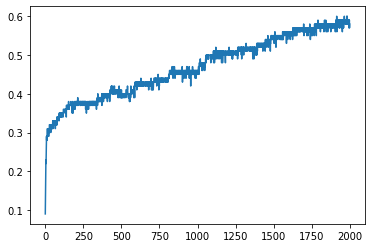

In [156]:
plt.plot(best_trace)

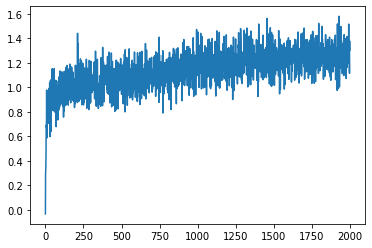

In [157]:
plt.plot(reward_trace)